<a href="https://colab.research.google.com/github/ver1812/Capstone_Project/blob/main/models/DistilBERT_Colab_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning — DistilBERT

**Colab + Drive, first of six planned transformer notebooks** (DistilBERT, BERT-base, RoBERTa-base, ELECTRA-base, DeBERTa-v3-base, ModernBERT-base).

In [1]:
import os
import json
import time
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

try:
    import transformers
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "transformers"], check=True)
    import transformers

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

print(f"transformers version: {transformers.__version__}")
print(f"torch version: {torch.__version__}")


transformers version: 5.13.1
torch version: 2.11.0+cu128


### Environment setup (Colab)

In [2]:
import platform

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("=== ENVIRONMENT CHECK ===")
print(f"Platform:       {platform.system()} {platform.machine()}")
print(f"IN_COLAB:       {IN_COLAB}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:            {torch.cuda.get_device_name(0)}")
    print(f"GPU memory:     {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: no GPU detected — check Runtime > Change runtime type > GPU.")

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/Capstone" if IN_COLAB else ".."
DATA_DIR = f"{BASE_DIR}/data_v2"
print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")


=== ENVIRONMENT CHECK ===
Platform:       Linux x86_64
IN_COLAB:       True
CUDA available: True
GPU:            Tesla T4
GPU memory:     15.6 GB
Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/Capstone
DATA_DIR: /content/drive/MyDrive/Capstone/data_v2


### Config

In [3]:
SEED = 42

MODEL_NAME = "distilbert-base-uncased"
MODEL_SLUG = "distilbert"

# Data
TEXT_COL = "text"
LABEL_COL = "label"

# Sequence — 512 is a hard architectural ceiling for DistilBERT, not a free choice
MAX_LEN = None  # locked below after checking real coverage at the 512 cap

# Training — standard transformer fine-tuning defaults
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.1
MAX_EPOCHS = 8    # corrected from 4 — the original Kaggle run undertrained
PATIENCE = 3      # corrected from 2, same reason
GRAD_CLIP = 1.0
USE_AMP = True    # mixed precision — genuinely useful for a Transformer's dense attention

# Artifacts — Capstone/saved/{MODEL_SLUG} on Drive
SAVE_DIR = f"{BASE_DIR}/saved/{MODEL_SLUG}"
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = USE_AMP and DEVICE.type == "cuda"
# ------------------------------------------------------------------


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Model: {MODEL_NAME}")
print(f"AMP enabled: {AMP_ENABLED}")
print(f"Save dir: {SAVE_DIR}")


Device: cuda
GPU: Tesla T4
Model: distilbert-base-uncased
AMP enabled: True
Save dir: /content/drive/MyDrive/Capstone/saved/distilbert


In [4]:
TRAIN_PATH = f"{DATA_DIR}/train_v2.csv"
VAL_PATH   = f"{DATA_DIR}/val_v2.csv"
TEST_PATH  = f"{DATA_DIR}/test_v2.csv"

for _name, _path in [("train_v2.csv", TRAIN_PATH), ("val_v2.csv", VAL_PATH), ("test_v2.csv", TEST_PATH)]:
    if not os.path.exists(_path):
        raise FileNotFoundError(
            f"{_name} not found at {_path} — check DATA_DIR is correct and the "
            "files actually live in that Drive folder."
        )


def load_split(path, text_col, label_col):
    frame = pd.read_csv(path)
    frame[text_col] = frame[text_col].fillna("").astype(str)
    frame[label_col] = frame[label_col].astype(int)
    return frame


train_df = load_split(TRAIN_PATH, TEXT_COL, LABEL_COL)
val_df   = load_split(VAL_PATH,   TEXT_COL, LABEL_COL)
test_df  = load_split(TEST_PATH,  TEXT_COL, LABEL_COL)

for name, frame in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{name:<6} {len(frame):>7,} rows | {frame[LABEL_COL].mean():.4f} positive")


Train   14,429 rows | 0.4784 positive
Val      3,092 rows | 0.4783 positive
Test     3,093 rows | 0.4785 positive


### Tokenizer & sequence length


In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Real token counts with NO truncation, to see the true distribution
train_encodings_full = tokenizer(list(train_df[TEXT_COL]), truncation=False)
train_lengths = np.array([len(ids) for ids in train_encodings_full["input_ids"]])

percentiles = [50, 75, 90, 95, 97, 99]
print("WordPiece token-length percentiles (train set, DistilBERT tokenizer):")
for p in percentiles:
    print(f"  p{p:>2}: {int(np.percentile(train_lengths, p)):>6,}")
print(f"  max: {train_lengths.max():>6,}")
print(f" mean: {train_lengths.mean():>6.1f}")

del train_encodings_full


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1716 > 512). Running this sequence through the model will result in indexing errors


WordPiece token-length percentiles (train set, DistilBERT tokenizer):
  p50:    119
  p75:    199
  p90:    359
  p95:    883
  p97:  1,012
  p99:  2,446
  max:  4,734
 mean:  217.8


In [6]:
MAX_LEN = 512  # hard architectural ceiling for DistilBERT

coverage_overall = (train_lengths <= MAX_LEN).mean()
coverage_benign = (train_lengths[train_df[LABEL_COL].values == 0] <= MAX_LEN).mean()
coverage_malicious = (train_lengths[train_df[LABEL_COL].values == 1] <= MAX_LEN).mean()

print(f"MAX_LEN = {MAX_LEN}")
print(f"Overall coverage:   {coverage_overall:.2%}")
print(f"Benign coverage:    {coverage_benign:.2%}")
print(f"Malicious coverage: {coverage_malicious:.2%}")


MAX_LEN = 512
Overall coverage:   93.05%
Benign coverage:    93.34%
Malicious coverage: 92.73%


### Dataset & DataLoader

In [7]:
class TransformerPromptDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(list(texts), truncation=True, max_length=max_len, padding=False)
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item


data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

train_ds = TransformerPromptDataset(train_df[TEXT_COL], train_df[LABEL_COL], tokenizer, MAX_LEN)
val_ds   = TransformerPromptDataset(val_df[TEXT_COL],   val_df[LABEL_COL],   tokenizer, MAX_LEN)
test_ds  = TransformerPromptDataset(test_df[TEXT_COL],  test_df[LABEL_COL],  tokenizer, MAX_LEN)

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=generator, collate_fn=data_collator)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator)

print(f"Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")


Batches — train: 902, val: 194, test: 194


### Model

In [8]:
# num_labels=1: single logit output
# loss is computed manually below with BCEWithLogitsLoss +
# pos_weight, same as every other model in this project.
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model on device: {next(model.parameters()).device}")


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     66,954,241
Trainable parameters: 66,954,241
Model on device: cuda:0


### Loss, optimizer, scheduler

In [9]:
num_neg = int((train_df[LABEL_COL] == 0).sum())
num_pos = int((train_df[LABEL_COL] == 1).sum())
pos_weight_value = num_neg / num_pos

print(f"Negatives: {num_neg:,} | Positives: {num_pos:,}")
print(f"pos_weight = {pos_weight_value:.4f}")

pos_weight = torch.tensor([pos_weight_value], dtype=torch.float, device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

total_steps = len(train_loader) * MAX_EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

print(f"Total optimizer steps: {total_steps:,} (warmup: {warmup_steps:,})")


Negatives: 7,526 | Positives: 6,903
pos_weight = 1.0903
Total optimizer steps: 7,216 (warmup: 721)


/tmp/ipykernel_1446/3435023473.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


### Train and evaluate functions

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler, device, grad_clip, epoch_num, total_epochs, print_every=40):
    model.train()
    running_loss = 0.0
    n_batches = len(loader)
    batch_start = time.time()

    for batch_idx, batch in enumerate(loader, start=1):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits.squeeze(-1)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item() * input_ids.size(0)

        if batch_idx == 1 or batch_idx % print_every == 0 or batch_idx == n_batches:
            elapsed = time.time() - batch_start
            avg_batch_time = elapsed / batch_idx
            eta_sec = avg_batch_time * (n_batches - batch_idx)
            print(
                f"  [Epoch {epoch_num}/{total_epochs}] batch {batch_idx}/{n_batches} "
                f"| loss {loss.item():.4f} | {avg_batch_time:.2f}s/batch | ETA {eta_sec:.0f}s",
                flush=True,
            )

    return running_loss / len(loader.dataset)


def predict(model, loader, criterion, device, desc="eval"):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits.squeeze(-1)
                loss = criterion(logits, labels)

            running_loss += loss.item() * input_ids.size(0)

            probs = torch.sigmoid(logits.float())
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    return avg_loss, np.concatenate(all_labels), np.concatenate(all_probs)


### Helper functions

In [11]:
def evaluate_predictions(y_true, y_prob, threshold=0.5, split_name=""):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "split": split_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
    }


def print_metrics(metrics):
    print(f"--- {metrics['split']} (threshold={metrics['threshold']:.2f}) ---")
    for key in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]:
        print(f"  {key:<10}: {metrics[key]:.4f}")


Quick timing check

In [13]:
model.train()
single_batch = next(iter(train_loader))
input_ids = single_batch["input_ids"].to(DEVICE)
attention_mask = single_batch["attention_mask"].to(DEVICE)
labels = single_batch["labels"].to(DEVICE)

start = time.time()
optimizer.zero_grad()
with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = outputs.logits.squeeze(-1)
    loss = criterion(logits, labels)
scaler.scale(loss).backward()
scaler.unscale_(optimizer)
nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
scaler.step(optimizer)
scaler.update()
scheduler.step()
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
batch_time = time.time() - start

print(f"Single batch time ({DEVICE}, AMP={AMP_ENABLED}, MAX_LEN={MAX_LEN}, batch={BATCH_SIZE}): {batch_time:.3f}s")
print(f"Batches per epoch: {len(train_loader)}")
print(f"Rough epoch estimate: {batch_time * len(train_loader) / 60:.1f} min")
print(f"Rough {MAX_EPOCHS}-epoch estimate: {batch_time * len(train_loader) * MAX_EPOCHS / 60:.1f} min")



/tmp/ipykernel_1446/1489721777.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


Single batch time (cuda, AMP=True, MAX_LEN=512, batch=16): 0.260s
Batches per epoch: 902
Rough epoch estimate: 3.9 min
Rough 8-epoch estimate: 31.2 min


### Training loop

In [14]:
best_val_f1 = -1.0
best_epoch = -1
epochs_without_improvement = 0
history = []

checkpoint_dir = os.path.join(SAVE_DIR, f"{MODEL_SLUG}_best")

print(f"Starting training — up to {MAX_EPOCHS} epochs, early stopping patience={PATIENCE}\n")

for epoch in range(1, MAX_EPOCHS + 1):
    start = time.time()

    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, scheduler, scaler,
        DEVICE, GRAD_CLIP, epoch, MAX_EPOCHS
    )
    val_loss, val_true, val_prob = predict(model, val_loader, criterion, DEVICE, desc=f"Epoch {epoch}/{MAX_EPOCHS} [val]")
    val_metrics = evaluate_predictions(val_true, val_prob, 0.5, "val")

    elapsed = time.time() - start

    history.append({
        "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
        "val_f1": val_metrics["f1"], "val_recall": val_metrics["recall"],
        "val_precision": val_metrics["precision"], "seconds": elapsed,
    })

    print(
        f"Epoch {epoch:>2}/{MAX_EPOCHS} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} "
        f"| val_F1 {val_metrics['f1']:.4f} | val_recall {val_metrics['recall']:.4f} | {elapsed:.1f}s"
    )

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch
        epochs_without_improvement = 0
        model.save_pretrained(checkpoint_dir)
        tokenizer.save_pretrained(checkpoint_dir)
        print("         -> new best val F1, checkpoint saved")
    else:
        epochs_without_improvement += 1
        print(f"         -> no improvement ({epochs_without_improvement}/{PATIENCE})")
        if epochs_without_improvement >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}. Best epoch: {best_epoch}, best val F1: {best_val_f1:.4f}.")
            break

history_df = pd.DataFrame(history)
print(f"\nTraining complete. Best val F1 = {best_val_f1:.4f} at epoch {best_epoch}")


Starting training — up to 8 epochs, early stopping patience=3



/tmp/ipykernel_1446/1074905201.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


  [Epoch 1/8] batch 1/902 | loss 0.7378 | 0.29s/batch | ETA 257s
  [Epoch 1/8] batch 40/902 | loss 0.7241 | 0.17s/batch | ETA 150s
  [Epoch 1/8] batch 80/902 | loss 0.7321 | 0.17s/batch | ETA 143s
  [Epoch 1/8] batch 120/902 | loss 0.6676 | 0.17s/batch | ETA 136s
  [Epoch 1/8] batch 160/902 | loss 0.6067 | 0.17s/batch | ETA 127s
  [Epoch 1/8] batch 200/902 | loss 0.4477 | 0.17s/batch | ETA 122s
  [Epoch 1/8] batch 240/902 | loss 0.5972 | 0.17s/batch | ETA 115s
  [Epoch 1/8] batch 280/902 | loss 0.5451 | 0.18s/batch | ETA 109s
  [Epoch 1/8] batch 320/902 | loss 0.3834 | 0.18s/batch | ETA 103s
  [Epoch 1/8] batch 360/902 | loss 0.2980 | 0.18s/batch | ETA 96s
  [Epoch 1/8] batch 400/902 | loss 0.2141 | 0.18s/batch | ETA 90s
  [Epoch 1/8] batch 440/902 | loss 0.5542 | 0.18s/batch | ETA 83s
  [Epoch 1/8] batch 480/902 | loss 0.3695 | 0.18s/batch | ETA 75s
  [Epoch 1/8] batch 520/902 | loss 0.3271 | 0.18s/batch | ETA 68s
  [Epoch 1/8] batch 560/902 | loss 0.3846 | 0.18s/batch | ETA 61s
  [Ep

/tmp/ipykernel_1446/1074905201.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


Epoch  1/8 | train_loss 0.4187 | val_loss 0.2744 | val_F1 0.8956 | val_recall 0.8411 | 174.5s


...

         -> new best val F1, checkpoint saved


/tmp/ipykernel_1446/1074905201.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


  [Epoch 8/8] batch 1/902 | loss 0.0029 | 0.21s/batch | ETA 191s
  [Epoch 8/8] batch 40/902 | loss 0.2194 | 0.20s/batch | ETA 169s
  [Epoch 8/8] batch 80/902 | loss 0.1267 | 0.19s/batch | ETA 159s
  [Epoch 8/8] batch 120/902 | loss 0.1838 | 0.19s/batch | ETA 152s
  [Epoch 8/8] batch 160/902 | loss 0.0033 | 0.19s/batch | ETA 143s
  [Epoch 8/8] batch 200/902 | loss 0.0080 | 0.19s/batch | ETA 134s
  [Epoch 8/8] batch 240/902 | loss 0.0035 | 0.19s/batch | ETA 127s
  [Epoch 8/8] batch 280/902 | loss 0.0014 | 0.19s/batch | ETA 119s
  [Epoch 8/8] batch 320/902 | loss 0.0003 | 0.19s/batch | ETA 111s
  [Epoch 8/8] batch 360/902 | loss 0.1440 | 0.19s/batch | ETA 104s
  [Epoch 8/8] batch 400/902 | loss 0.0120 | 0.19s/batch | ETA 96s
  [Epoch 8/8] batch 440/902 | loss 0.2753 | 0.19s/batch | ETA 89s
  [Epoch 8/8] batch 480/902 | loss 0.0105 | 0.19s/batch | ETA 81s
  [Epoch 8/8] batch 520/902 | loss 0.0033 | 0.19s/batch | ETA 73s
  [Epoch 8/8] batch 560/902 | loss 0.0077 | 0.19s/batch | ETA 66s
  [E

/tmp/ipykernel_1446/1074905201.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


Epoch  8/8 | train_loss 0.0409 | val_loss 0.3934 | val_F1 0.9288 | val_recall 0.9080 | 183.6s
         -> no improvement (1/3)

Training complete. Best val F1 = 0.9295 at epoch 7


### Load checkpoint and evaluate

In [16]:
model = AutoModelForSequenceClassification.from_pretrained(checkpoint_dir).to(DEVICE)

_, val_true, val_prob = predict(model, val_loader, criterion, DEVICE, desc="final val")
val_metrics = evaluate_predictions(val_true, val_prob, 0.5, "val")
print_metrics(val_metrics)

_, test_true, test_prob = predict(model, test_loader, criterion, DEVICE, desc="final test")
test_metrics = evaluate_predictions(test_true, test_prob, 0.5, "test")
print_metrics(test_metrics)

print("\nConfusion matrix (test, threshold=0.5):")
test_pred = (test_prob >= 0.5).astype(int)
cm = confusion_matrix(test_true, test_pred)
print(pd.DataFrame(cm, index=["actual_benign", "actual_malicious"], columns=["pred_benign", "pred_malicious"]))

print("\n" + classification_report(test_true, test_pred, digits=4))


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

/tmp/ipykernel_1446/1074905201.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


--- val (threshold=0.50) ---
  accuracy  : 0.9340
  precision : 0.9512
  recall    : 0.9087
  f1        : 0.9295
  roc_auc   : 0.9741
  pr_auc    : 0.9778


/tmp/ipykernel_1446/1074905201.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


--- test (threshold=0.50) ---
  accuracy  : 0.9289
  precision : 0.9430
  recall    : 0.9061
  f1        : 0.9242
  roc_auc   : 0.9726
  pr_auc    : 0.9764

Confusion matrix (test, threshold=0.5):
                  pred_benign  pred_malicious
actual_benign            1532              81
actual_malicious          139            1341

              precision    recall  f1-score   support

         0.0     0.9168    0.9498    0.9330      1613
         1.0     0.9430    0.9061    0.9242      1480

    accuracy                         0.9289      3093
   macro avg     0.9299    0.9279    0.9286      3093
weighted avg     0.9294    0.9289    0.9288      3093



ROC curve

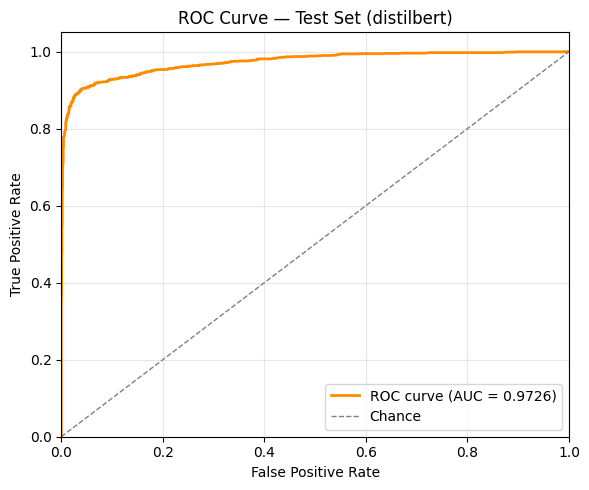

Saved: /content/drive/MyDrive/Capstone/saved/distilbert/roc_curve_distilbert.png


In [17]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(test_true, test_prob)
roc_auc_value = test_metrics["roc_auc"]

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc_value:.4f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Chance")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — Test Set ({MODEL_SLUG})")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

roc_path = os.path.join(SAVE_DIR, f"roc_curve_{MODEL_SLUG}.png")
plt.savefig(roc_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {roc_path}")


Confusion matrix (visual)

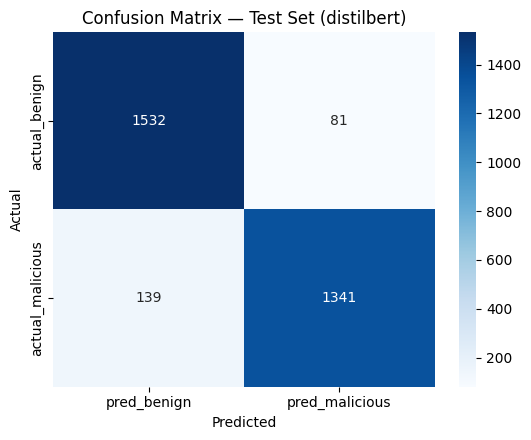

Saved: /content/drive/MyDrive/Capstone/saved/distilbert/confusion_matrix_distilbert.png


In [18]:
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["pred_benign", "pred_malicious"],
    yticklabels=["actual_benign", "actual_malicious"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — Test Set ({MODEL_SLUG})")
plt.tight_layout()

cm_path = os.path.join(SAVE_DIR, f"confusion_matrix_{MODEL_SLUG}.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {cm_path}")


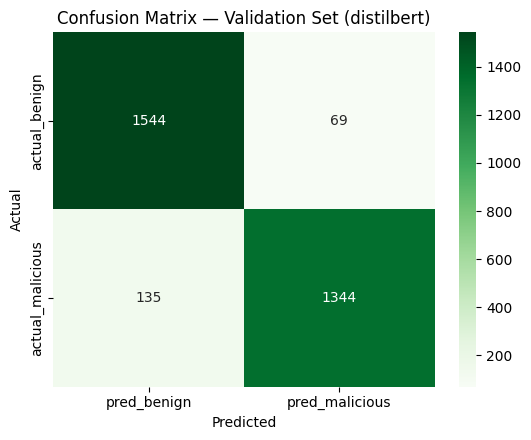

Saved: /content/drive/MyDrive/Capstone/saved/distilbert/confusion_matrix_val_distilbert.png


In [19]:
val_pred = (val_prob >= 0.5).astype(int)
val_cm = confusion_matrix(val_true, val_pred)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    val_cm, annot=True, fmt="d", cmap="Greens",
    xticklabels=["pred_benign", "pred_malicious"],
    yticklabels=["actual_benign", "actual_malicious"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — Validation Set ({MODEL_SLUG})")
plt.tight_layout()

val_cm_path = os.path.join(SAVE_DIR, f"confusion_matrix_val_{MODEL_SLUG}.png")
plt.savefig(val_cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {val_cm_path}")

### Save metrics/history

In [20]:
config = {
    "seed": SEED,
    "model_name": MODEL_NAME,
    "model_slug": MODEL_SLUG,
    "max_len": MAX_LEN,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "warmup_ratio": WARMUP_RATIO,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "grad_clip": GRAD_CLIP,
    "amp_enabled": AMP_ENABLED,
    "pos_weight": pos_weight_value,
    "best_epoch": best_epoch,
    "best_val_f1": best_val_f1,
    "total_params": total_params,
    "trainable_params": trainable_params,
    "device": str(DEVICE),
}
with open(os.path.join(SAVE_DIR, "config_{MODEL_SLUG}.json"), "w") as f:
    json.dump(config, f, indent=2)

results = pd.DataFrame([val_metrics, test_metrics])
results.to_csv(os.path.join(SAVE_DIR, "metrics_{MODEL_SLUG}.csv"), index=False)
history_df.to_csv(os.path.join(SAVE_DIR, "history_{MODEL_SLUG}.csv"), index=False)

print("Saved:")
for root, dirs, files in os.walk(SAVE_DIR):
    for f in files:
        print(f"  {os.path.join(root, f)}")

results


Saved:
  /content/drive/MyDrive/Capstone/saved/distilbert/loss_curve_distilbert.png
  /content/drive/MyDrive/Capstone/saved/distilbert/roc_curve_distilbert.png
  /content/drive/MyDrive/Capstone/saved/distilbert/confusion_matrix_distilbert.png
  /content/drive/MyDrive/Capstone/saved/distilbert/confusion_matrix_val_distilbert.png
  /content/drive/MyDrive/Capstone/saved/distilbert/config_{MODEL_SLUG}.json
  /content/drive/MyDrive/Capstone/saved/distilbert/metrics_{MODEL_SLUG}.csv
  /content/drive/MyDrive/Capstone/saved/distilbert/history_{MODEL_SLUG}.csv
  /content/drive/MyDrive/Capstone/saved/distilbert/distilbert_best/config.json
  /content/drive/MyDrive/Capstone/saved/distilbert/distilbert_best/model.safetensors
  /content/drive/MyDrive/Capstone/saved/distilbert/distilbert_best/tokenizer_config.json
  /content/drive/MyDrive/Capstone/saved/distilbert/distilbert_best/tokenizer.json


,split,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,val,0.5,0.934023,0.951168,0.908722,0.929461,0.974081,0.977760
1,test,0.5,0.928872,0.943038,0.906081,0.924190,0.972633,0.976353


Results summary (JSON, matches the traditional ML / BiLSTM v2 format — includes raw confusion-matrix counts)

In [21]:
tn, fp, fn, tp = cm.ravel()

results_summary = {
    MODEL_SLUG: {
        "config": MODEL_SLUG,
        "validation": val_metrics,
        "test": test_metrics,
        "test_confusion_matrix": {
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        },
    }
}

results_json_path = os.path.join(SAVE_DIR, f"{MODEL_SLUG}_results.json")
with open(results_json_path, "w") as f:
    json.dump(results_summary, f, indent=2)

print(f"Saved results summary to {results_json_path}")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")


Saved results summary to /content/drive/MyDrive/Capstone/saved/distilbert/distilbert_results.json
TN=1532, FP=81, FN=139, TP=1341


Zip artifacts for download

In [22]:
import shutil

zip_path = shutil.make_archive(
    base_name=f"{BASE_DIR}/{MODEL_SLUG}_artifacts",
    format="zip",
    root_dir=SAVE_DIR,
)
print(f"Zipped to: {zip_path}")
print(f"Size: {os.path.getsize(zip_path) / 1e6:.2f} MB")


Zipped to: /content/drive/MyDrive/Capstone/distilbert_artifacts.zip
Size: 247.42 MB
